In [6]:
# Read Excel file
import pandas as pd

filepath = "./survey.xlsx"
excel = pd.ExcelFile(filepath)

df = excel.parse(excel.sheet_names[0])

df.columns = [col.strip() for col in df.columns]
df.columns

Index(['ID', 'Start time', 'Completion time', 'Email', 'Name',
       'Last modified time',
       'I think that I would like to use this system frequently',
       'I found the system unnecessarily complex.',
       'I thought the system was easy to use.',
       'I think that I would need the support of a technical person to be able to use this system.',
       'I found the various functions in this system were well integrated.',
       'I thought there was too much inconsistency in this system.',
       'I would imagine that most people would learn to use this system very quickly.',
       'I found the system very cumbersome to use.',
       'I felt very confident using the system.',
       'I needed to learn a lot of things before I could get going with this system.',
       'I felt emotionally connected to Grace.',
       'Grace’s behavior reflected how I was feeling during gameplay.',
       'The game responded to my emotional state in helpful ways.',
       'I felt supported by 

In [8]:
new_columns = {
    'I think that I would like to use this system frequently': 'SUS Q1',
    'I found the system unnecessarily complex.': 'SUS Q2',
    'I thought the system was easy to use.': 'SUS Q3',
    'I think that I would need the support of a technical person to be able to use this system.': 'SUS Q4',
    'I found the various functions in this system were well integrated.': 'SUS Q5',
    'I thought there was too much inconsistency in this system.': 'SUS Q6',
    'I would imagine that most people would learn to use this system very quickly.': 'SUS Q7',
    'I found the system very cumbersome to use.': 'SUS Q8',
    'I felt very confident using the system.': 'SUS Q9',
    'I needed to learn a lot of things before I could get going with this system.': 'SUS Q10',
    'I felt emotionally connected to Grace.': 'Custom Q1',
    "Grace’s behavior reflected how I was feeling during gameplay.": 'Custom Q2',
    'The game responded to my emotional state in helpful ways.': 'Custom Q3',
    'I felt supported by Grace during moments of difficulty.': 'Custom Q4',
    'The emotional feedback made the game feel more personalized.': 'Custom Q5',
    'The adaptive suggestions appeared at appropriate times.': 'Custom Q6',
    'I felt in control of my gameplay even when suggestions were offered.': 'Custom Q7',
    'The emotional feedback enhanced my overall game experience.': 'Custom Q8',
    'I enjoyed interacting with Grace throughout the game.': 'Custom Q9',
    'I would like to continue playing or exploring more levels of this game.': 'Custom Q10',
    'I felt motivated to continue the story.': 'Custom Q11',
    'The narrative helped me stay engaged with the game.': 'Custom Q12',
    'What did you think of Grace as a companion during the game?': 'Open Q1',
    "Were there any moments when Grace’s responses helped, surprised, or confused you?": 'Open Q2',
    "Is there anything you would improve or change about the game or Grace’s behavior?": 'Open Q3',
    'Did the game respond to your emotions in ways that felt natural or helpful? Why or why not?': 'Open Q4',
    'Did the story or characters make the gameplay feel more meaningful? Why or why not?': 'Open Q5'
}
df.rename(columns=new_columns, inplace=True)
df.columns

Index(['ID', 'Start time', 'Completion time', 'Email', 'Name',
       'Last modified time', 'SUS Q1', 'SUS Q2', 'SUS Q3', 'SUS Q4', 'SUS Q5',
       'SUS Q6', 'SUS Q7', 'SUS Q8', 'SUS Q9', 'SUS Q10', 'Custom Q1',
       'Custom Q2', 'Custom Q3', 'Custom Q4', 'Custom Q5', 'Custom Q6',
       'Custom Q7', 'Custom Q8', 'Custom Q9', 'Custom Q10', 'Custom Q11',
       'Custom Q12', 'Open Q1', 'Open Q2', 'Open Q3', 'Open Q4', 'Open Q5'],
      dtype='object')

In [9]:
# Drop columns that are not used in our analysis
dropped_cols = ['ID', 'Start time', 'Completion time', 'Email', 'Name', 'Last modified time']

df_cleaned = df.drop(labels=dropped_cols, axis=1)
df_cleaned.columns

Index(['SUS Q1', 'SUS Q2', 'SUS Q3', 'SUS Q4', 'SUS Q5', 'SUS Q6', 'SUS Q7',
       'SUS Q8', 'SUS Q9', 'SUS Q10', 'Custom Q1', 'Custom Q2', 'Custom Q3',
       'Custom Q4', 'Custom Q5', 'Custom Q6', 'Custom Q7', 'Custom Q8',
       'Custom Q9', 'Custom Q10', 'Custom Q11', 'Custom Q12', 'Open Q1',
       'Open Q2', 'Open Q3', 'Open Q4', 'Open Q5'],
      dtype='object')

In [35]:
# Map responses to numerical values
response_mapper = {
    'none': 0,
    'strongly disagre': 1,
    'strongly disagree': 1,
    'disagree': 2,
    'neutral': 3,
    'agree': 4,
    'strongly agree': 5
}

In [36]:
# Extract columns that use likert scale
df_likert = df_cleaned.iloc[:, :-5]
df_likert.head()

,SUS Q1,SUS Q2,SUS Q3,SUS Q4,SUS Q5,SUS Q6,SUS Q7,SUS Q8,SUS Q9,SUS Q10,...,Custom Q3,Custom Q4,Custom Q5,Custom Q6,Custom Q7,Custom Q8,Custom Q9,Custom Q10,Custom Q11,Custom Q12
0,Agree,Disagree,Strongly Agree,Strongly Disagre,Strongly Agree,Disagree,Strongly Agree,Strongly Disagre,Strongly Agree,Strongly Disagre,...,Agree,Agree,Strongly agree,Neutral,Disagree,Agree,Strongly agree,Strongly agree,Strongly agree,Agree
1,Disagree,Disagree,Disagree,Agree,Neutral,Agree,Agree,Disagree,Agree,Strongly Disagre,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree
2,Agree,Disagree,Agree,Agree,Agree,Disagree,Neutral,Disagree,Agree,Agree,...,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Agree,Agree,Agree,Agree
3,Disagree,Neutral,Agree,Disagree,Neutral,Strongly Disagre,Disagree,Agree,Neutral,Strongly Disagre,...,Agree,Agree,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree,Neutral
4,Strongly Agree,Disagree,Agree,Disagree,Disagree,Disagree,Agree,Disagree,Agree,Disagree,...,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree


In [37]:
# Map string values to numerical values
df_likert = df_likert.map(lambda x: response_mapper.get(str(x).strip().lower(), None))
df_likert.head()

,SUS Q1,SUS Q2,SUS Q3,SUS Q4,SUS Q5,SUS Q6,SUS Q7,SUS Q8,SUS Q9,SUS Q10,...,Custom Q3,Custom Q4,Custom Q5,Custom Q6,Custom Q7,Custom Q8,Custom Q9,Custom Q10,Custom Q11,Custom Q12
0,4,2,5,1,5,2,5,1,5,1,...,4,4,5,3,2,4,5,5,5,4
1,2,2,2,4,3,4,4,2,4,1,...,5,5,5,5,5,5,5,5,5,5
2,4,2,4,4,4,2,3,2,4,4,...,3,3,3,3,3,3,4,4,4,4
3,2,3,4,2,3,1,2,4,3,1,...,4,4,3,5,3,4,4,4,4,3
4,5,2,4,2,2,2,4,2,4,2,...,4,4,4,4,4,4,4,4,4,4


In [40]:
df_sus = df_likert.iloc[:, :10]
df_cus = df_likert.iloc[:, 11:]

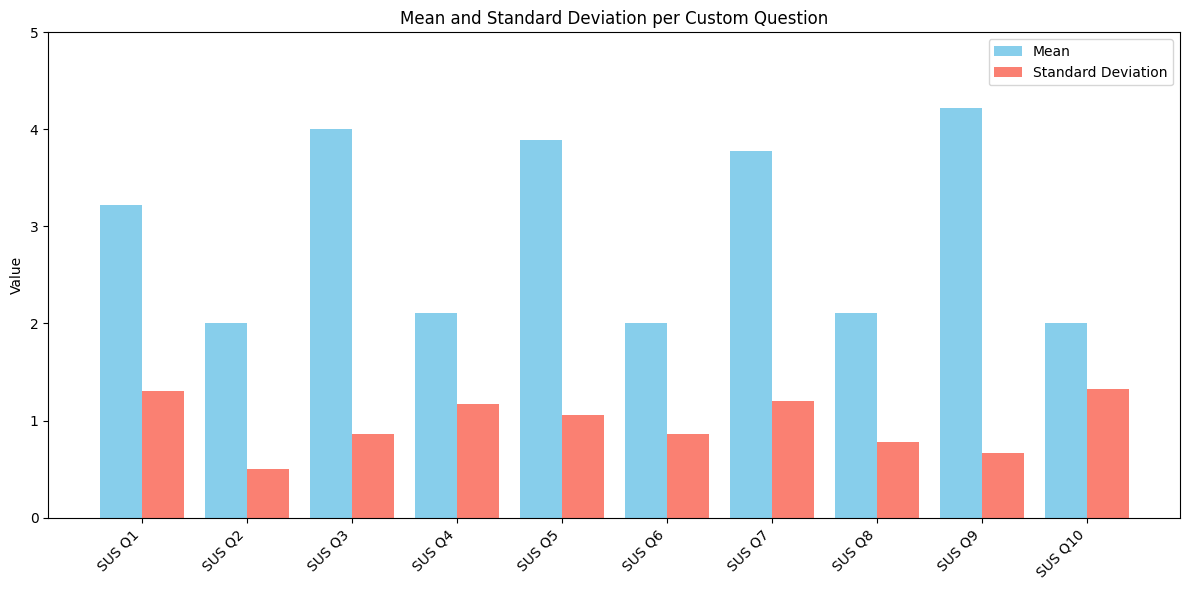

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mean and standard deviation
means = df_sus.mean()
stds = df_sus.std()

# Set up the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Set bar positions
x = range(len(df_sus.columns))

# Plot mean bars
ax.bar(x, means, width=0.4, label='Mean', align='center', color='skyblue')

# Plot std bars next to them
ax.bar([i + 0.4 for i in x], stds, width=0.4, label='Standard Deviation', align='center', color='salmon')

# Add labels and legend
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(df_sus.columns, rotation=45, ha='right')
ax.set_ylabel('Value')
ax.set_title('Mean and Standard Deviation per Custom Question')
ax.set_ylim(0, 5)
ax.legend()

plt.tight_layout()
plt.show()